In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("products_asos.csv", on_bad_lines = "skip")
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"Data Loaded: {len(df)}")
df.head()

Data Loaded: 18378


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [2]:
#Collecting Brand Name from Description


#1. Convert the data in description column to string
df['description'] = df['description'].astype(str)

#2. Splitting the brand name from Description
def get_brand(text):
  if 'by ' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unknown"
  else:
    return "Unknown"

df['brand'] = df['description'].apply(get_brand)

In [3]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [9]:
###Brand Mapping

#Since the brand name has only 1 word, we have to map it to the actual brand name
#Before we create a map, check the unique names in the brand


#By running the below command, we can see that there are more than 200
#brands and we cant clean everything... so we only include the brands
#that is repeated more than 5 times.

# unique_brands = df['brand'].unique()
# for brand in unique_brands:
#     print(brand)

brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop',
    'StradivariusJacket': 'Stradivarius',
    'JDYLow-key': 'JDY',
    'Native': 'Native Youth',
    'ColumbiaExclusive': 'Columbia',
    'BershkaLow-key': 'Bershka',
    'ZaraLow-key': 'Zara'
}

df['brand'] = df['brand'].map(brand_map).fillna(df['brand'])

# Keep only brands with more than 5 items
brand_counts = df['brand'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index
df_clean = df[df['brand'].isin(valid_brands)].copy()

print(df_clean['brand'].value_counts())

brand
ASOS                 4844
Topshop              1017
New Look              511
River Island          467
Miss Selfridge        429
                     ... 
TopshopAdd-to-bag       6
Pull&BearCan't          6
BershkaShort            6
BershkaStyle            6
BershkaMake             6
Name: count, Length: 338, dtype: int64


In [11]:
##Calculating the Stockouts:

def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0

  #Data is in format "UK 6, UK 8 - Out of stock"
  #so we have to split them using delimiter = ','
  sizes = size_str.split(',')
  total_sizes = len(sizes)

  #count how many items are out of stock
  out_of_stock_count = size_str.count('Out of stock')

  #Calculate the rate (0.0 to 1.0)
  rate = out_of_stock_count / total_sizes if total_sizes>0 else 0.0

  return out_of_stock_count, rate

metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Rate'] = [x[1] for x in metrics]

df_clean['Lost_Revenue'] = df_clean['Stockout_Count'] * df_clean['price']

cols = ['brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue']
print(df_clean[cols].sort_values(by='Lost_Revenue', ascending=False).head(5)[cols])

         brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


/tmp/ipykernel_3980/599556118.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


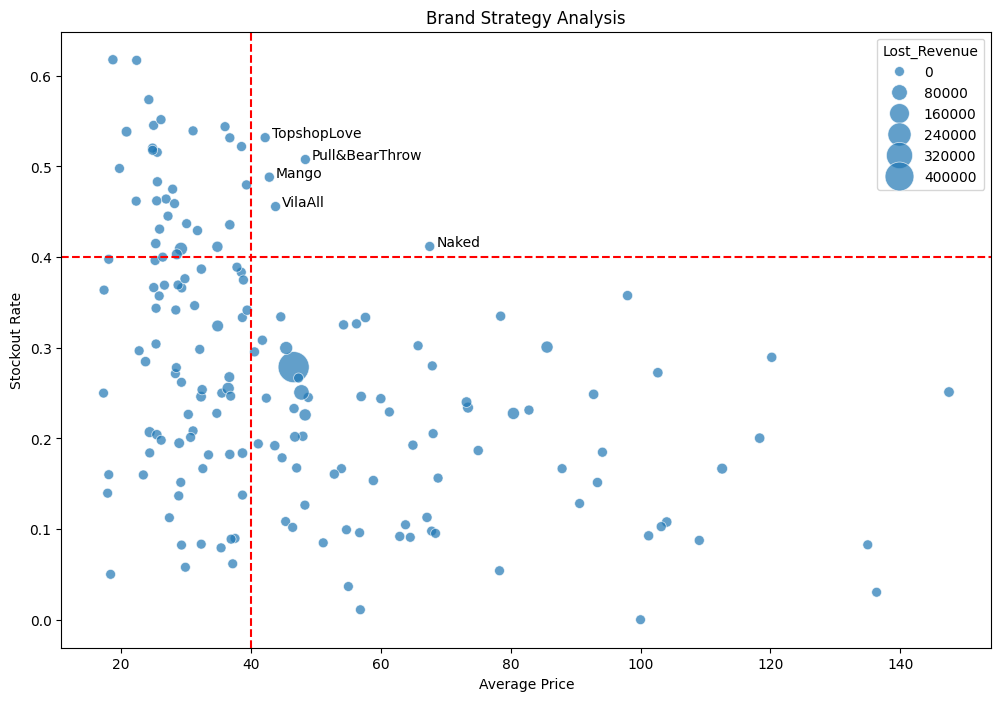

In [16]:
brand_strategy = df_clean.groupby('brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size='Lost_Revenue',
    sizes=(50,500),
    palette='viridis',
    alpha=0.7
)


#The below block of code will name only the points in the top right corner
winners = brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate']>0.4)
]

for i in range(len(winners)):
  plt.text(
      winners.iloc[i]['price']+1,
      winners.iloc[i]['Stockout_Rate'],
      winners.iloc[i]['brand']
  )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')

plt.show()

In [17]:
###Stockout Rate : Stockout rate is the percentage of times an item is out of stock when there is customer demand for it.

#Stockout rate shows how often a product is unavailable, directly indicating lost sales, customer dissatisfaction, and how well a business manages its inventory.

###From the above plot, we can infer that products in the top-right quadrant have high prices and high stockout rates, indicating strong demand despite premium pricing.
###These products are likely significant contributors to revenue and also represent areas of potential revenue loss due to insufficient stock.